## Notes

C NOT = CX

In the teleportation,we make a projection on the first quit (teleportation). In principle we have to divide the output state by normalizatoiion factor. First qubit becomes and eigenstate. We have a separation in between. It partially destroys the coherence. The measurement is after the Hadamard gate. 

We measure Q, if Q is 0 alpha |0> + beta |1>, p is 1/2. 
If Q is 1, we have alpha |0> - beta |1> = |A>

In total we have 4 options from the Q measurement and RA measurement.

A 0, Q 0 -> alpha |0> + beta |1>, p = 1/4 // original state

But the other states are not much different.
We can flip the qubit. If the measurement of Q or A is 1, we can flip the qubit to get the original state.
R state is a rotation.

A 0, Q 1 -> alpha |0> - beta |1>, p = 1/4
A 1, Q 0 -> alpha |0> + beta |1>, p = 1/4
A 1, Q 1 -> alpha |0> - beta |1>, p = 1/4

Two lines are conditional not controlled. 
Changed orders in the CX gates in the circuit does not change the output state.
We can also put the second and third lines in the circuit in any order (upside down) 

In [75]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot 
import numpy as np

In [76]:
def run_and_plot_meas(circuit, circuit_name, backend = AerSimulator(), N = 1000):

    sampler = Sampler(backend)
    job=sampler.run([circuit], shots=N)
    result =job.result()

    for i in range(len(result)):
        counts = result[i].data.meas.get_counts()
        print(f"Wyniki dla obwodu {circuit_name}: {counts}")
    
    fig = circuit.draw("mpl")
    
    return fig

In [77]:
def run_and_plot_c(circuit, circuit_name, backend = AerSimulator(), N = 1000):

    sampler = Sampler(backend)
    job=sampler.run([circuit], shots=N)
    result =job.result()

    for i in range(len(result)):
        counts = result[i].data.c.get_counts()
        print(f"Wyniki dla obwodu {circuit_name}: {counts}")
    
    fig = circuit.draw("mpl")
    
    return fig

## Swap with a zero

In [78]:
# circuit parameters
Q = 2
q0 = 0
q1 = 1

C = 2
c0 = 0
c1 = 1

a0 = np.pi/8

In [79]:
qc_swap = QuantumCircuit(Q) 
qc_swap.rx(a0, c0)
qc_swap.cx(q0,q1)
qc_swap.cx(q1,q0)
qc_swap.rx(-a0, c1)

qc_swap.measure_all()

Wyniki dla obwodu SWAP: {'00': 1000}


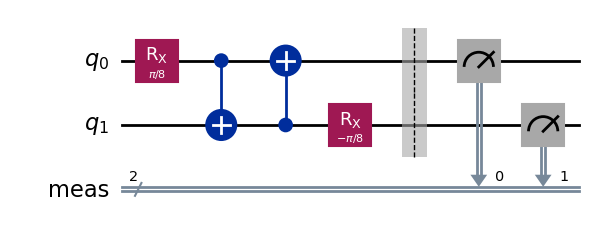

In [80]:
fig_swap = run_and_plot_meas(qc_swap, 'SWAP')
fig_swap

Jest okej, mamy obydwa na zero.

## Full swap

In [81]:
# circuit parameters
Q = 2
q0 = 0
q1 = 1

C = 2
c0 = 0
c1 = 1

a0 = np.pi/8
a1 = np.pi/4

In [82]:
qc_full_swap = QuantumCircuit(Q) 

qc_full_swap.rx(a0, c0)
qc_full_swap.rx(a1, c1)

qc_full_swap.cx(q0,q1)
qc_full_swap.cx(q1,q0)
qc_full_swap.cx(q0,q1)

qc_full_swap.rx(-a0, c1)
qc_full_swap.rx(-a1, c0)

qc_full_swap.measure_all()

Wyniki dla obwodu FULL_SWAP: {'00': 1000}


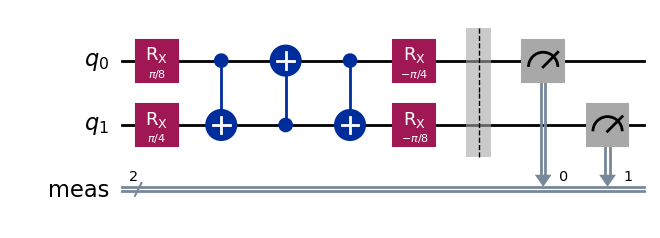

In [83]:
fig_full_swap = run_and_plot_meas(qc_full_swap, 'FULL_SWAP')
fig_full_swap

## Teleportation

In [84]:
# circuit parameters
Q = 3
q0 = 0
q1 = 1
q2 = 2

C = 3
c0 = 0
c1 = 1
c2 = 2

a0 = np.pi/8

In [85]:
qc_teleportation = QuantumCircuit(Q, C) 

qc_teleportation.rx(a0, c0) # prepare Q
qc_teleportation.cx(q0,q1)

qc_teleportation.h(q2)
qc_teleportation.cx(q2,q1)

qc_teleportation.h(q0)
qc_teleportation.measure(q0, c0)

qc_teleportation.h(q0)
with qc_teleportation.if_test((c0,1)) as other:
    qc_teleportation.z(q2)

qc_teleportation.measure(q1,c1)

with qc_teleportation.if_test((c1,1)) as other:
    qc_teleportation.x(q2)

qc_teleportation.rx(-a0, q2)
qc_teleportation.measure(q2,c2)

Wyniki dla obwodu TELEPORTATION: {'011': 243, '000': 258, '010': 253, '001': 246}


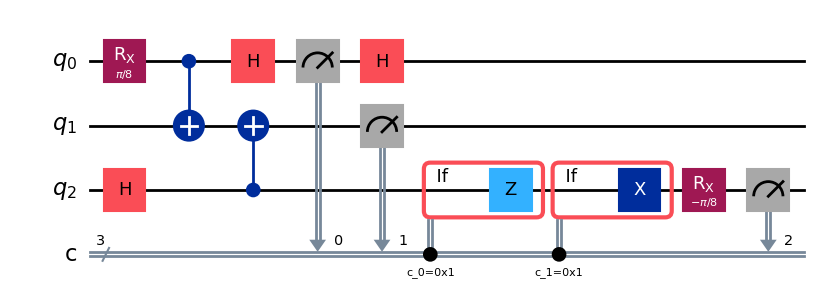

In [86]:
fig_teleportation= run_and_plot_c(qc_teleportation, 'TELEPORTATION')
fig_teleportation